# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## Assignment Notebook: **Building Agents using LangGraph**

(Without OpenAI API)

## **Objective**

The objective of this assignment is to help you understand how to design and build intelligent agents using LangGraph.

By the end of this assignment, you will be able to:

* Create agent workflows that can **reason, make decisions, and interact with tools or external systems** in a structured and controlled manner
* Design **single-agent workflows** with tool integration
* Build **multi-agent systems** with a supervisor for task orchestration
* Control execution flow using **states, nodes, and edges**
* Develop systems capable of **reasoning, decision-making, and task delegation**


## **Introduction**

**LangGraph**

LangGraph is an open-source framework from LangChain for ***building stateful, multi-actor AI applications using graphs***.

---
<br>

With the rise of agentic AI systems, traditional linear workflows are evolving into dynamic, decision-driven processes. LangGraph enables developers to build such systems by representing agents as graphs, where nodes define actions (like tool usage or LLM calls) and edges control the flow of execution.

In this assignment, you will explore how to construct agent-based workflows using LangGraph, implement multi-step reasoning using patterns like ReAct, and integrate external tools to perform real-world tasks. This hands-on exercise will provide practical exposure to building scalable, modular, and intelligent AI agents.

<br>

---
<br>

**LangChain vs LangGraph – Brief Comparison**

**LangChain** is a framework designed to build applications powered by Large Language Models (LLMs). It focuses on ***chaining together components*** such as prompts, models, memory, and tools in a mostly linear or sequential flow. It is ideal for use cases like chatbots, Q&A systems, and simple tool integrations where the workflow follows a defined path.

On the other hand, **LangGraph** extends LangChain by enabling developers to design ***stateful, multi-step, and non-linear workflows*** using a graph-based approach. Instead of simple chains, LangGraph allows branching, looping, and conditional execution, making it better suited for building agents that require reasoning, decision-making, and coordination between multiple steps or tools.

In short:

* **LangChain** → Best for linear workflows and quick LLM applications
* **LangGraph** → Best for complex, agentic workflows with control over execution flow

---
---

In this notebook, we will be building two workflows:

* I. Agent–Tool Graph (Single-Agent Workflow)

* II. Agent Supervisor Graph (Multi-Agent Workflow)


### **I. Agent–Tool Graph (Single-Agent Workflow)**

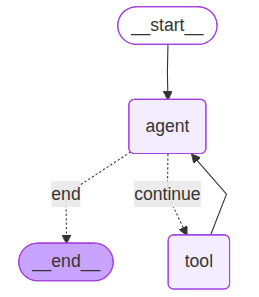

This graph represents a **basic agentic workflow** built using LangGraph, where a single agent interacts with external tools to complete a task.

* The flow begins at the **start node**, which triggers the execution.
* The **agent node** acts as the decision-maker. It interprets the user input and decides the next step.
* If the task requires external information or action, the agent moves to the **tool node** (e.g., API call, database query).
* After receiving the tool output, control returns to the agent for further reasoning.
* This loop continues until the agent decides to **end** the process.

**Key Idea:**

This graph demonstrates the **ReAct pattern (Reason + Act)** — where the agent alternates between thinking and using tools.

**Use Case Examples:**

* Fetching weather data
* Querying a database
* Performing calculations via tools

---


### **II. Agent Supervisor Graph (Multi-Agent Workflow)**

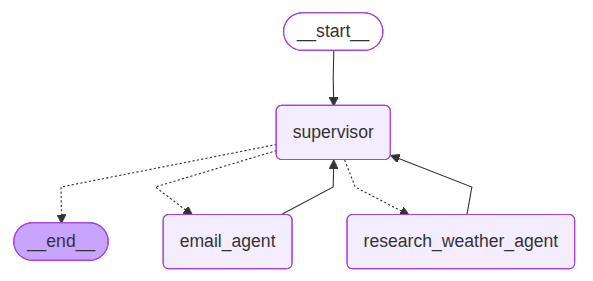

This graph represents a more advanced **multi-agent system** coordinated by a supervisor using LangGraph.

* The workflow starts at the **start node**, which passes control to the **supervisor agent**.
* The **supervisor** acts as an orchestrator—it does not perform tasks itself but decides **which specialized agent should handle the request**.
* Based on the task, it delegates work to:

  * **email_agent** → handles communication-related tasks
  * **research_weather_agent** → handles research or weather queries
* After task execution, results are passed back to the supervisor.
* The supervisor either:

  * Routes to another agent (if needed), or
  * Ends the workflow.

**Key Idea:**

This graph demonstrates **agent orchestration and delegation**, where multiple agents collaborate under a central controller.

**Use Case Examples:**

* Business workflow automation
* Customer support systems
* Multi-step decision-making pipelines

---


### **Setup Steps:**

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "" #@param {type:"string"}

In [ ]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "" #@param {type:"string"}

In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()

notebook= "M5_AST_02_Building_Agents_using_LangGraph"   #name of the notebook

batchId = "IISC-AC-GENAI-02"


def print_message(message: str, color: str = "red"):
    display(HTML(f"<span style='color:{color};'>{message}</span>"))

def setup():
#  ipython.magic("sx pip3 install torch")

    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/submissions/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print_message(r["err"])
        return None
      else:
        print_message("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,
              "batch" : batchId
            }
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")

### Install required dependencies

In [ ]:
%%capture
!pip -q install openai==2.3.0
!pip -q install langchain-core==0.3.79
!pip -q install langchain-community==0.3.31
!pip -q install sentence-transformers==5.1.1
!pip -q install langchain-huggingface==0.3.1
!pip -q install langchain-experimental==0.3.4
!pip -q install langchainhub==0.1.21
!pip -q install langchain-openai==0.3.35

# Install LangGraph
!pip -q install langgraph==0.6.8
!pip -q install langgraph-supervisor==0.0.29

# for google-search as a tool
!pip -q install serpapi==0.1.5
!pip -q install google-search-results==2.4.2

### Import required packages

In [ ]:
import os
import re
import json
from google.colab import userdata

import openai
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

from langchain import hub
from langchain.agents import load_tools

### **Provide your Groq API key**

In [ ]:
# Save the key in Colab's Secrets then load from there

from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get("GROQ_API_KEY")

### **Load your Language Model**

In [ ]:
from langchain_openai import ChatOpenAI

llm_llama = ChatOpenAI(
    model="llama-3.3-70b-versatile",   # Groq-supported model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

llm_gpt = ChatOpenAI(
    model="openai/gpt-oss-120b",   # Groq-supported model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

# We are going to use this language model as the reasoning engine of the agent to connect to other data sources and perform computation
# so we want this reasoning engine to be as presice as possible.
# Hence, temperature is set to zero to get rid of any randomness.

In [ ]:
response = llm_llama.invoke("What is 2 plus 3")
print(response.content)

In [ ]:
response = llm_gpt.invoke("What is 2 plus 3")
print(response.content)

# **I. Agent–Tool Graph (Single-Agent Workflow)**

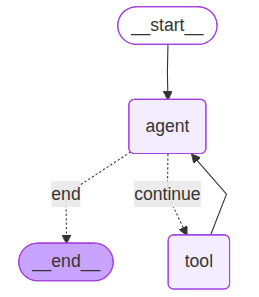

## **Create Custom Tools to add to the Agent**

### **1. Tool to Do a Web Search**


Certain tools require API Keys. In this example, we use SerpAPI.

Create a new free account and generate your Serp API KEY HERE:
https://serpapi.com/manage-api-key

Under free plan, it offers limited number of searches to perform (250 searches / month).

In [ ]:
# Add your SerpAPI key to Colab Secrets with name 'SERPAPI_KEY' then run this cell

serp_api_key = userdata.get('SERPAPI_KEY')
os.environ["SERPAPI_API_KEY"] = serp_api_key

In [ ]:
# Create Tool to do Web Search

from serpapi.google_search import GoogleSearch    # Import the GoogleSearch class from the SerpAPI library
                                                  # This allows programmatic Google searches via SerpAPI.

def do_web_search(query):
    """
    Perform a Google web search using SerpAPI and return a simplified list
    of the top organic search results.
    """

    # Parameters for the search query
    params = {
        "q": query,                     # Search query string
        "num": 1,                       # Number of results to fetch (top 1 result here)
        "google_domain": "google.com",  # Google domain to use for the search
        "api_key": serp_api_key         # Your SerpAPI key for authentication
    }

    # Initialize the GoogleSearch object with the parameters
    search = GoogleSearch(params)

    # Execute the search and get the full results as a Python dictionary
    results = search.get_dict()

    # Extract only essential fields from the organic search results
    slim_result = []
    for r in results.get("organic_results", []):
        slim_result.append(
            {
                "title": r.get("title"),       # Title of the search result page
                "link": r.get("link"),         # Direct URL to the page
                "source": r.get("source"),     # Source site or domain (if provided)
                "date": r.get("date"),         # Publish or announcement date (if available)
                "snippet": r.get("snippet"),   # Short text snippet/preview from the page
            }
        )

    # Return the simplified list of result dictionaries
    return slim_result[0]


In [ ]:
# Create the tool to pass to an agent

from langchain_core.tools import Tool

web_search_tool = Tool(
    name="web_search_tool",
    description="""Perform web search for the given input query.\
    The input should always be a string representing a query to search on web or internet, \
    and this function will always return a list of json object with the web search results. """,
    func = do_web_search,
)

### **2. Tool to Send an Email**

To send an email message programatically using Python, we need to use App Password.

**How to create and use an App Password?**

An app password is a 16-digit passcode that gives a less secure app or device permission to access your Google Account.

**Note:** App passwords can only be used with Google accounts that have 2-Step Verification turned on.

**To get your account App Password,**

1. Go to your Google Account.
2. Select Security.
3. In the search bar, search for App passwords.
4. Enter a name that helps you remember where you’ll use the app password.
5. Select Generate.
6. Copy the generated app password. Remove spaces in between, it is a 16-character code.
7. Select Done.

If you’ve set up 2-Step Verification but can’t find the option to add an app password, it might be because:

1. Your Google Account has 2-Step Verification set up only for security keys.
2. You’re logged into a work, school, or another organization account.
3. Your Google Account has Advanced Protection.


In [ ]:
# Standard library for sending email using the Simple Mail Transfer Protocol (SMTP)
import smtplib

# Classes for creating email content and multi-part (e.g., text + attachments) messages
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# Utility to format the “From” header with a display name plus email address
from email.utils import formataddr

In the below code, we are extracting **structured email information from unstructured text** using an LLM with LangChain.

* A `Pydantic` model (`MailInfo`) defines the expected schema (receiver email, subject, body).

* A `PydanticOutputParser` ensures the LLM output adheres to this structure.

* A prompt template instructs the model to return the extracted details in JSON format.

* The LLM processes a natural language email request, and the parser converts the response into a validated Python object, allowing easy access to the extracted fields.

In [ ]:
from pydantic import BaseModel, Field

# Pydantic
class MailInfo(BaseModel):
    """ Product service info."""
    receiver_email: str = Field(description="Recipient's email address")
    subject: str = Field(description="Subject line of the email")
    body: str = Field(description="Message body of the email (plain text)")


In [ ]:
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

# Instantiate Parser
pydantic_parser = PydanticOutputParser(pydantic_object=MailInfo)

In [ ]:
extract_email_fields_prompt_template = """\
For the following email request, extract the following information:

receiver_email: Recipient's email address

subject: Subject line of the email

body: Message body of the email (plain text)

Format the output as JSON with the following keys:
receiver_email
subject
body

text: {text}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt_template = ChatPromptTemplate.from_template(extract_email_fields_prompt_template)
print(prompt_template)

In [ ]:
sample_prompt = '''\
Send an email to "yograj.mahawar03@gmail.com"
Subject: Product Feedback
Mail Body:
"""
Hi there, We found your product to be of great quality.
Thanks
"""
'''

messages = prompt_template.format_messages(text=sample_prompt)
messages

In [ ]:
res = llm_llama.invoke(messages)
res

In [ ]:
mail_info = pydantic_parser.invoke(res)
mail_info

In [ ]:
# Extracted fields
print(f"Receiver Email: {mail_info.receiver_email}")
print(f"Subject: {mail_info.subject}")
print(f"Body: {mail_info.body}")

In [ ]:
# Create Tool to send an email

def send_email(email_request):
    """
    Send a plain-text email using Gmail's SMTP server.

    Parameters:
        email_request (str): The details of the mail to be sent
    """

    # Extract receiver_email, subject, body
    messages = prompt_template.format_messages(text=email_request)
    llm_output = llm_llama.invoke(messages)
    mail_info = pydantic_parser.invoke(llm_output)
    receiver_email = mail_info.receiver_email
    subject = mail_info.subject
    body = mail_info.body

    # ---- SMTP Configuration ----
    smtp_server = "smtp.gmail.com"        # Gmail SMTP server
    smtp_port = 587                       # Port for TLS encryption
    sender_name = "Support Team"          # Display name that appears to the recipient
    sender_email = "yograj.mahawar03@gmail.com"  # <------- REPLACE with your own email address
    app_password = "rmxlrllnumjhmaji"         # <------- REPLACE with your app password

    # ---- Compose the Email ----
    message = MIMEMultipart()                                 # Create a multi-part email container
    message["From"] = formataddr((sender_name, sender_email)) # Add sender name + email
    message["To"] = receiver_email                            # Add recipient address
    message["Subject"] = subject                              # Add subject line
    message.attach(MIMEText(body, "plain"))                   # Attach the email body as plain text

    # ---- Send the Email ----
    try:
        # Connect to the SMTP server and secure the connection
        with smtplib.SMTP(smtp_server, smtp_port) as server:
            server.starttls()                                                   # Start TLS encryption for security
            server.login(sender_email, app_password)                                # Log in using the sender's credentials
            server.sendmail(sender_email, receiver_email, message.as_string())  # Send the email
        return "Email sent successfully!"
    except Exception as e:
        # Print and return an error message if sending fails
        print(f"Error sending message: {e}")
        return "Email could not be delivered!"


In [ ]:
# Create the tool to pass to an agent

from langchain_core.tools import Tool

send_email_tool = Tool(
    name="send_email_tool",
    description="""Send an email based on the email request. \
    The input should always be a string representing the email request including sender email id, subject and body. \
    This function will always return a text message stating if the email is sent successfully. """,
    func = send_email,
)

### **3. Tool to make a Weather API call**

**OpenWeather** is a weather data provider that uses AI and machine learning to offer historical, current, and forecasted weather data for any location worldwide via light-speed APIs.

Open Weather Map is [integrated](https://python.langchain.com/docs/integrations/tools/openweathermap) into LangChain.

We need to install `pyown`, create an API key on the website of Open Weather Map (which takes a few hours to activate) and then run the cells below to get weather of a given city.

In [ ]:
!pip -q install pyowm==3.5.0

In [ ]:
# Load the API key
os.environ["OPENWEATHERMAP_API_KEY"] = userdata.get("OPENWEATHERMAP_API_KEY")

In [ ]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper

weather = OpenWeatherMapAPIWrapper()

In [ ]:
weather_data = weather.run("Las Vegas")
print(weather_data)

In [ ]:
# Create the tool to pass to an agent

from langchain_core.tools import Tool

weather_tool = Tool(
    name="weather_tool",
    description="""Get the weather details for the given city.\
    The input should always be a string representing the city name, \
    and this function will always return a json format response with weather details. """,
    func = weather.run,
)

**Create a function to call these tools**

In [ ]:
# Create a function to call these tools

all_tools = {"web_search_tool": web_search_tool,
             "send_email_tool": send_email_tool,
             "weather_tool": weather_tool}

def call_tool(tool_name, tool_input):
    func = all_tools[tool_name]
    tool_output = func.run(tool_input)
    return tool_output


In [ ]:
print(call_tool('weather_tool', 'Las Vegas'))

## **Create Agent & Tool Nodes**

In [ ]:
# Load tools

tools = load_tools([], llm=llm_llama) + [web_search_tool, send_email_tool, weather_tool]
tools

In the below code, we are enabling **tool calling with an LLM** using LangChain.

* The available tools are first converted into OpenAI-compatible function schemas using `convert_to_openai_function`, allowing the model to understand their purpose and parameters.

* These functions are then bound to the LLM using `bind_tools`, enabling it to decide when to call a tool based on user input.


In [ ]:
tools[0]

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_function

convert_to_openai_function(tools[0])

In [ ]:
convert_to_openai_function(tools[1])

In [ ]:
# Convert all tools to OpenAI Functions (to bind it with the LLM)

functions = [convert_to_openai_function(t) for t in tools]
llm_with_tools = llm_llama.bind_tools(functions)

In [ ]:
functions

In [ ]:
# llm.invoke("what is the temperature in las vegas")

# llm_with_tools.invoke("what is the temperature in las vegas")

### **Define AgentState**

(To keep track of the intermediate outputs from LLM and Tools)

* In LangGraph, `AgentState` is used to **store and manage the shared state (e.g., messages, data)** that flows between different nodes in the graph.
* It ensures that each step in the workflow can **access, update, and maintain context** across multi-step agent execution.

---

**How the State will look like?**

```
{'messages': [
    SystemMessage()
    HumanMessage(content="what is the temperature in las vegas"),
    AIMessage(content="AI response"),
    ToolMessage(content="Tool output"),
    AIMessage(content="AI response"),
    ...
]}
```

---

In the below code, we are defining a **state structure for an agent workflow** using a `TypedDict` in the context of LangGraph.

* The `AgentState` contains a `messages` field, which stores a sequence of conversation messages (`BaseMessage`).

* The use of `Annotated[..., operator.add]` specifies how this state should be updated—new messages are **appended to the existing list** rather than replacing it.

* This enables the agent to maintain conversation history across steps, which is essential for **multi-step reasoning, context retention, and iterative decision-making** in graph-based agent workflows.


In [ ]:
# Define AgentState (To keep track of the intermediate outputs from LLM and Tools)

from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

* **TypedDict**: Defines a dictionary with **fixed keys and types** for better structure and type checking.

* **Annotated**: Adds **extra instructions/metadata** to a type. In this context, `Annotated[..., operator.add]` tells frameworks like LangGraph how to **update or merge the state** (i.e., append new messages instead of replacing them).

* **Sequence**: A generic type that represents an **ordered collection of elements** (like lists or tuples). Here, `Sequence[BaseMessage]` means a collection of message objects that maintain order, which is important for preserving conversation history.

* **BaseMessage**: A core message class in LangChain that represents a **single unit of conversation** (e.g., user, AI, or system message).

In [ ]:
# Define the Function/Logic that needs to be executed at the Agent Node

from langchain_core.messages import SystemMessage

def agent_node_function(state):
    # prepend a system instruction once, then ask the model
    if not any(m.type == "system" for m in state["messages"]):
        sys = SystemMessage(content=(
            "You are a helpful AI assistant with access to tools. "
            "Use tools when needed. If you can finalize, prefix with 'FINAL ANSWER'."
        ))
        msgs = [sys] + list(state["messages"])
    else:
        msgs = state["messages"]

    response = llm_with_tools.invoke(msgs)
    return {"messages": [response]}


In [ ]:
# Define the Function/Logic that needs to be executed at the Tool Node

import json
from langchain_core.messages import ToolMessage

def tool_node_function(state):
    messages = state['messages']
    last_message = messages[-1] # this has the query we need to send to the tool provided by the agent

    parsed_tool_input = json.loads(last_message.additional_kwargs['tool_calls'][0]['function']['arguments'])

    # Extract tool details
    tool_name = last_message.additional_kwargs['tool_calls'][0]['function']['name']
    tool_input = parsed_tool_input['__arg1']
    tool_call_id = last_message.additional_kwargs['tool_calls'][0]['id']

    # Call tool
    tool_response = call_tool(tool_name = tool_name,
                              tool_input = tool_input)

    # Use the response to create a ToolMessage
    function_message = ToolMessage(content=str(tool_response),
                                   name=tool_name,
                                   tool_call_id=tool_call_id)

    # Return a list, because this will get added to the existing list
    return {"messages": [function_message]}


In [ ]:
# Define the Function/Logic that needs to be used to decide when to go to the Tool Node

from langchain_core.messages import AIMessage, ToolMessage

def where_to_go(state):
    last_msg = state["messages"][-1]
    # If the assistant asked to call tools, LangChain exposes them as `tool_calls`
    if isinstance(last_msg, AIMessage) and getattr(last_msg, "tool_calls", None):
        return "continue"
    return "end"


### **Build an Agent–Tool Workflow using LangGraph**

In the below code, we are defineing a **graph-based agent workflow** using LangGraph, where execution is controlled through nodes and edges.

* A `StateGraph` is initialized with `AgentState`, and two nodes are added:
    * an **agent node** (decision-making) and
    * a **tool node** (external action).

* The workflow uses `add_conditional_edges` to decide the next step after the agent runs—based on the function `where_to_go`, the flow either continues to the tool (`"continue"`) or ends (`END`).

* A fixed edge ensures that after the tool executes, control always returns to the agent.

* Finally, the agent is set as the entry point, and the graph is compiled into an executable app, enabling a loop where the agent can reason, call tools, and decide when to stop.


In [ ]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node_function)
workflow.add_node("tool", tool_node_function)

# The conditional edge requires the following info below.
# First, we define the start node. We use `agent`.
# This means these are the edges taken after the `agent` node is called.
# Next, we pass in the function that will determine which node is called next, in our case where_to_go().

workflow.add_conditional_edges("agent", where_to_go, {   # Based on the return from where_to_go
                                                         # If return is "continue" then we call the tool node.
                                                         "continue": "tool",
                                                         # Otherwise we finish. END is a special node marking that the graph should finish.
                                                         "end": END
                                                     }
)

# We now add a normal edge from `tools` to `agent`.
# This means that if `tool` is called, then it has to call the 'agent' next.
workflow.add_edge('tool', 'agent')

# Basically, agent node has the option to call a tool node based on a condition,
# whereas tool node must call the agent in all cases based on this setup.

workflow.set_entry_point("agent")


app = workflow.compile()


In [ ]:
#@title Load the function `display_workflow_graph()`

## Render a LangGraph-style Mermaid string in Jupyter/Colab

from IPython.display import HTML, display
import json, re

def display_workflow_graph(workflow_app):
    mermaid_str = workflow_app.get_graph().draw_mermaid()
    s = str(mermaid_str).strip()
    cfg_json = "{}"

    # Extract optional YAML front-matter like:
    # ---
    # config:
    #   flowchart:
    #     curve: linear
    # ---
    m = re.match(r"^---\s*(.*?)\s*---\s*(graph\s+\w+;.*)$", s, re.S)
    if m:
        yaml_block, diagram = m.group(1), m.group(2)
        try:
            import yaml  # pip install pyyaml (only once if missing)
            data = yaml.safe_load(yaml_block) or {}
            cfg_json = json.dumps(data.get("config", {}))
        except Exception:
            diagram = s.split('---')[-1].strip()
    else:
        diagram = s

    # Convert YAML config to Mermaid init directive + embed and render
    directive = f"%%{{init: {cfg_json}}}%%\n"
    html = f"""
    <div class="mermaid">
    {directive}
    {diagram}
    </div>
    <script>
    (function() {{
      function boot() {{
        if (window.mermaid) {{
          mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
          mermaid.contentLoaded();
        }} else {{
          var s = document.createElement('script');
          s.src = "https://cdn.jsdelivr.net/npm/mermaid/dist/mermaid.min.js";
          s.onload = function() {{
            mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
            mermaid.contentLoaded();
          }};
          document.head.appendChild(s);
        }}
      }}
      boot();
    }})();
    </script>
    """
    display(HTML(html))


In [ ]:
display_workflow_graph(app)

In [ ]:
# Test the Graph for a sample input

from langchain_core.messages import HumanMessage

input = {"messages": [HumanMessage(content="what is the temperature in las vegas")]}
result = app.invoke(input)

print(result['messages'][-1].content)

In [ ]:
result

Create a Function to see the Intermediate steps output

In [ ]:
# Show Intermediate Steps

def show_intermediate_steps(result):
    for msg in result['messages']:
        # Print whether its a HumanMessage, AIMessage, ToolMessage
        print(f"\n{type(msg).__name__:<13}--->  ", end='')
        # If the intermediate step is a tool call or a response
        if msg.content == '':
            func_name = msg.additional_kwargs['tool_calls'][0]['function']['name']
            print(f"Calling `{func_name}`")
        else:
            print(msg.content)


In [ ]:
show_intermediate_steps(result)

In [ ]:
# Test the Graph

input = {"messages": [HumanMessage(content="Send an email saying 'Hello! This is a test msg.' with subject 'TEST' to `yograj.mahawar03@gmail.com` ")]}
result = app.invoke(input)

print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)



---



---



# **II. Agent Supervisor Graph (Multi-Agent Workflow)**

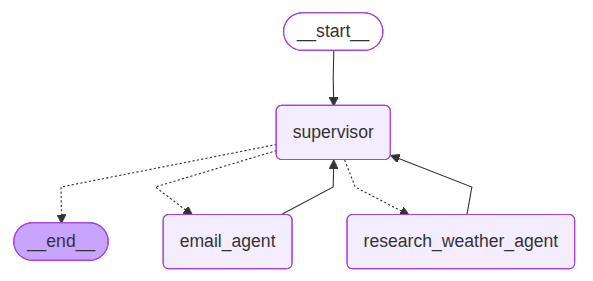

## **Create Research-Weather Agent** (Agent 1)

This agent is a **specialized ReAct-based agent** to handle **research and weather-related tasks**.

It is equipped with tools like `web_search_tool` and `weather_tool`, enabling it to fetch real-time information and respond with accurate results.

The below prompt acts as a system instruction (behavior guardrail) for this agent.

```
You are a research & weather agent.

INSTRUCTIONS:
- Assist ONLY with research-related and weather-related tasks,
- After you're done with your tasks, respond to the supervisor directly
- Respond ONLY with the results of your work, do NOT include ANY other text.
```

---

Earlier, we will build an **Agent–Tool Graph from scratch** by manually defining nodes and edges.

Here, instead of building the workflow step-by-step, we use `create_react_agent`, which provides a **prebuilt agent pattern (Reason + Act loop)**, making it faster and easier to implement tool-using agents within a larger multi-agent system.


In [ ]:
# Create Agent1

from langgraph.prebuilt import create_react_agent

research_weather_agent = create_react_agent(
    model=llm_gpt,
    tools=[web_search_tool, weather_tool],
    prompt=(
        "You are a research & weather agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related and weather-related tasks, \n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_weather_agent",
)

In [ ]:
display_workflow_graph(research_weather_agent)

In [ ]:
# Test the Agent node

from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

input = {"messages": [HumanMessage(content="who is the mayor of NYC?")]}
result = research_weather_agent.invoke(input)
print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)

In [ ]:
# Test the Agent node

input = {"messages": [HumanMessage(content="Zohran K. Mamdani is the mayor of which city, and whats the weather there")]}
result = research_weather_agent.invoke(input)
print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)

## **Create Email Agent** (Agent 2)

This agent is a **specialized ReAct-based agent** to handle **email-related tasks**, such as composing and sending emails.

The below prompt acts as a system instruction (behavior guardrail) for this agent.

```
You are an email agent.

INSTRUCTIONS:
- Assist ONLY with email sending related tasks
- After you're done with your tasks, respond to the supervisor directly
- Respond ONLY with the results of your work, do NOT include ANY other text.
```

In [ ]:
# Create Agent2

from langgraph.prebuilt import create_react_agent

email_agent = create_react_agent(
    model=llm_gpt,
    tools=[send_email_tool],
    prompt=(
        "You are an email agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with email sending related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="email_agent",
)

In [ ]:
display_workflow_graph(email_agent)

In [ ]:
from langchain_core.messages import HumanMessage

inputs = {"messages": [HumanMessage(content="Send an email saying 'Hello! This is a test msg.' to `yograj.mahawar03@gmail.com` with Subject: TEST ")]}
result = email_agent.invoke(inputs)
print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)

## **Create Supervisor**

The supervisor is a **central orchestration agent** that manages and coordinates multiple specialized agents.

* It does not perform tasks itself but **routes user requests to the appropriate agent** based on the task type.

* In this setup, the supervisor decides whether to assign the task to:

  * **Research–Weather Agent** → for research and weather-related queries
  * **Email Agent** → for email-sending tasks

The below prompt acts as a system instruction (behavior guardrail) for this agent.

```
You are a supervisor managing two agents:

- a research-weather agent. Assign research-related and weather related tasks to this agent
- an email agent. Assign email send related tasks to this agent
Assign work to one agent at a time, do not call agents in parallel.
Do not do any work yourself.
```

In [ ]:
# Create Supervisor

from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=llm_gpt,
    agents=[research_weather_agent, email_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research-weather agent. Assign research-related and weather related tasks to this agent\n"
        "- an email agent. Assign email send related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

In [ ]:
display_workflow_graph(supervisor)

In [ ]:
# Test the System with some input prompt

input = {"messages": [HumanMessage(content="Could you tell me when iPhone 17 was launched? Also, send the response directly in mail at yograj.mahawar03@gmail.com")]}
result = supervisor.invoke(input)
print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)

In [ ]:
# Test the System with some another input prompt

input = {"messages": [HumanMessage(content="Zohran K. Mamdani is the mayor of which city, and whats the weather there? Also, send the response directly in mail at `yograj.mahawar03@gmail.com`")]}
result = supervisor.invoke(input)
print(result['messages'][-1].content)

In [ ]:
show_intermediate_steps(result)

### Please answer the questions below to complete the experiment:




In [ ]:
#@title What is the key advantage of using create_react_agent instead of manually building an Agent-Tool graph? { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "" #@param ["", "It eliminates the need for defining external tools", "It automatically handles reasoning and tool selection steps", "It provides a prebuilt Reason + Act loop for faster development", "It removes the need for writing structured prompts"]

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [ ]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "" #@param {type:"string"}


In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "" #@param ["","Yes", "No"]


In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

---

<center>
$END$
</center>

---